In [1]:
# Data Manipulation & Array Operations
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Synthetic Datasets
from sklearn.datasets import make_moons, make_blobs

# Preprocessing & Scaling
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, DBSCAN

# Dimensionality Reduction
from sklearn.decomposition import PCA

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons

# 1. Generate synthetic make_moons dataset
X_moons, y_moons = make_moons(n_samples=500, noise=0.05, random_state=42)

# 2. Convert into a pandas DataFrame
df_moons = pd.DataFrame(X_moons, columns=['Feature1', 'Feature2'])

# 3. Display dataset shape
print(f"Dataset Shape: {df_moons.shape}\n")

# 4. Display the first 10 rows
print("First 10 Rows:")
print(df_moons.head(10))

Dataset Shape: (500, 2)

First 10 Rows:
   Feature1  Feature2
0  0.830586 -0.447733
1  0.701678  0.816918
2  1.022080 -0.492571
3 -0.316765  0.953438
4  0.293226  1.057185
5  1.254903 -0.483435
6  1.053851 -0.442690
7  0.031380  1.053012
8  0.620545  0.713096
9  1.787657 -0.142959


In [4]:
#Question 2: Scaling the Data
from sklearn.preprocessing import StandardScaler

# 1. Initialize StandardScaler
scaler = StandardScaler()

# 2. Fit and transform the dataset created in Q1
X_scaled = scaler.fit_transform(df_moons)

# 3. Convert X_scaled to DataFrame to neatly view the first 5 rows
df_scaled = pd.DataFrame(X_scaled, columns=['Feature1', 'Feature2'])

print("First 5 rows of X_scaled:")
print(df_scaled.head(5))

First 5 rows of X_scaled:
   Feature1  Feature2
0  0.375125 -1.403679
1  0.226815  1.135628
2  0.595442 -1.493710
3 -0.944918  1.409748
4 -0.243115  1.618062


K-Means Cluster Counts:
kmeans_cluster
0    255
1    245
Name: count, dtype: int64


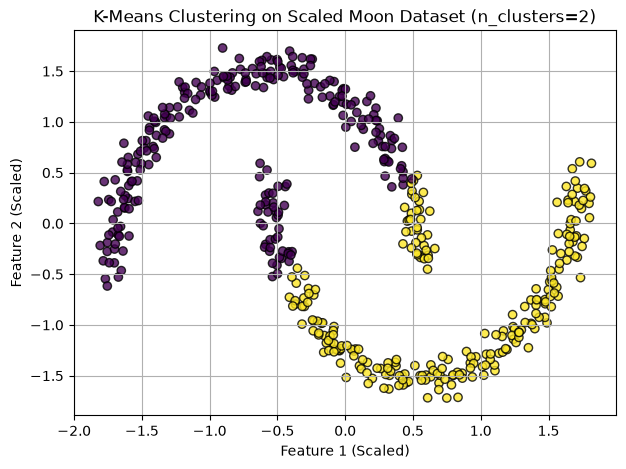

In [5]:
#Question 3: K-Means on Non-Linear Data
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Apply KMeans with n_clusters=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
df_moons['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# 2. Display value counts for predicted clusters
print("K-Means Cluster Counts:")
print(df_moons['kmeans_cluster'].value_counts())

# 3. Create Scatter Plot
plt.figure(figsize=(7, 5))
plt.scatter(
    X_scaled[:, 0], 
    X_scaled[:, 1], 
    c=df_moons['kmeans_cluster'], 
    cmap='viridis', 
    edgecolors='k', 
    alpha=0.8
)
plt.title("K-Means Clustering on Scaled Moon Dataset (n_clusters=2)")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.grid(True)
plt.show()

Cluster Distribution:
dbscan_cluster
0    250
1    250
Name: count, dtype: int64


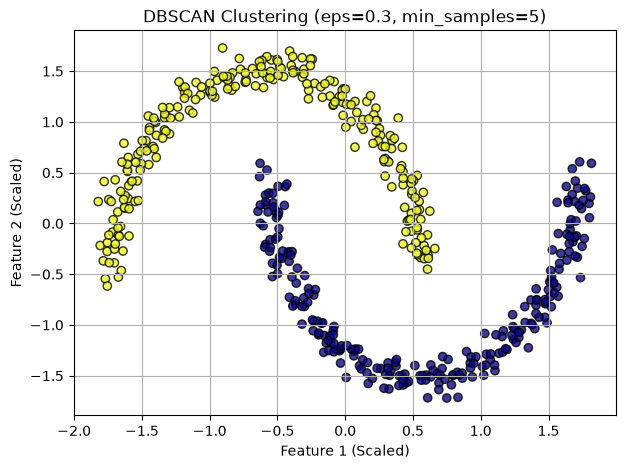

In [6]:
#Question 4: DBSCAN Clustering
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# 1. Apply DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
df_moons['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# 2. Display cluster counts
print("Cluster Distribution:")
print(df_moons['dbscan_cluster'].value_counts())

# 3. Create Scatter Plot
plt.figure(figsize=(7, 5))
plt.scatter(
    X_scaled[:, 0], 
    X_scaled[:, 1], 
    c=df_moons['dbscan_cluster'], 
    cmap='plasma', 
    edgecolors='k', 
    alpha=0.8
)
plt.title("DBSCAN Clustering (eps=0.3, min_samples=5)")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.grid(True)
plt.show()

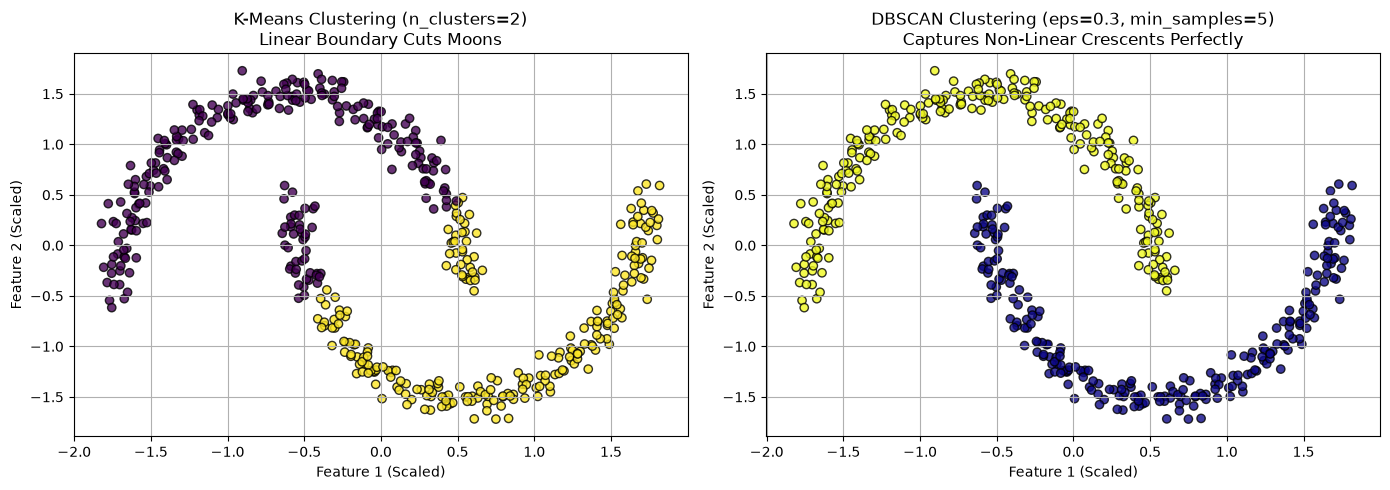

In [7]:
#Question 5: Comparing KMeans vs. DBSCAN
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN

# Setup figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot K-Means Results (Q3)
axes[0].scatter(
    X_scaled[:, 0], 
    X_scaled[:, 1], 
    c=df_moons['kmeans_cluster'], 
    cmap='viridis', 
    edgecolors='k', 
    alpha=0.8
)
axes[0].set_title("K-Means Clustering (n_clusters=2)\nLinear Boundary Cuts Moons")
axes[0].set_xlabel("Feature 1 (Scaled)")
axes[0].set_ylabel("Feature 2 (Scaled)")
axes[0].grid(True)

# 2. Plot DBSCAN Results (Q4)
axes[1].scatter(
    X_scaled[:, 0], 
    X_scaled[:, 1], 
    c=df_moons['dbscan_cluster'], 
    cmap='plasma', 
    edgecolors='k', 
    alpha=0.8
)
axes[1].set_title("DBSCAN Clustering (eps=0.3, min_samples=5)\nCaptures Non-Linear Crescents Perfectly")
axes[1].set_xlabel("Feature 1 (Scaled)")
axes[1].set_ylabel("Feature 2 (Scaled)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [8]:
#Question 6: Tuning DBSCAN Parameters
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN

# Define eps range
eps_values = [0.2, 0.3, 0.4, 0.5]
results = []

for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(X_scaled)
    
    # Exclude noise label (-1) when counting clusters
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    
    results.append({
        'eps': eps,
        'Number of Clusters': n_clusters,
        'Number of Noise Points': n_noise
    })

# Display summary table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 eps  Number of Clusters  Number of Noise Points
 0.2                   2                       0
 0.3                   2                       0
 0.4                   2                       0
 0.5                   2                       0


In [9]:
#Question 7: Creating High-Dimensional Dataset
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# 1. Generate 6D synthetic dataset
X_blobs, y_blobs = make_blobs(
    n_samples=500,
    n_features=6,
    centers=4,
    cluster_std=1.5,
    random_state=42
)

# 2. Scale the data using StandardScaler
scaler_blobs = StandardScaler()
X_blobs_scaled = scaler_blobs.fit_transform(X_blobs)

# 3. View shape and first 5 rows in DataFrame format
df_blobs_scaled = pd.DataFrame(
    X_blobs_scaled, 
    columns=[f'Feature_{i+1}' for i in range(6)]
)

print(f"Scaled Dataset Shape: {df_blobs_scaled.shape}\n")
print("First 5 Rows of Scaled Blobs Data:")
print(df_blobs_scaled.head(5))

Scaled Dataset Shape: (500, 6)

First 5 Rows of Scaled Blobs Data:
   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6
0  -1.052513   0.719083   0.350444   0.989657  -1.619597   1.414499
1   0.140795  -1.040620   0.841574  -0.857108   0.458731  -0.556293
2  -0.143302   1.113049   0.785668   0.686643  -0.153543  -1.524124
3  -1.093345   0.925894  -0.009533   1.108893  -1.371680   1.210841
4  -1.541419   0.736345   0.562503   1.015382  -0.375990   1.392803


In [10]:
#Question 8: Applying PCA
import pandas as pd
from sklearn.decomposition import PCA

# 1. Apply PCA to reduce dimensions to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_blobs_scaled)

# 2. Create DataFrame with columns PC1 and PC2
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# 3. Add original cluster labels
df_pca['Original_Label'] = y_blobs

# 4. Display Explained Variance Ratio
var_ratio = pca.explained_variance_ratio_

print("Explained Variance Ratio per Component:")
print(f"PC1: {var_ratio[0]:.4f} ({var_ratio[0]*100:.2f}%)")
print(f"PC2: {var_ratio[1]:.4f} ({var_ratio[1]*100:.2f}%)")
print(f"Total Retained Variance: {var_ratio.sum():.4f} ({var_ratio.sum()*100:.2f}%)\n")

print("First 5 Rows of PCA DataFrame:")
print(df_pca.head())

Explained Variance Ratio per Component:
PC1: 0.6433 (64.33%)
PC2: 0.2104 (21.04%)
Total Retained Variance: 0.8537 (85.37%)

First 5 Rows of PCA DataFrame:
        PC1       PC2  Original_Label
0  2.369765  1.259783               1
1 -0.943367 -0.829777               3
2  0.982191 -1.768556               0
3  2.265086  1.190377               1
4  2.142129  0.840804               1


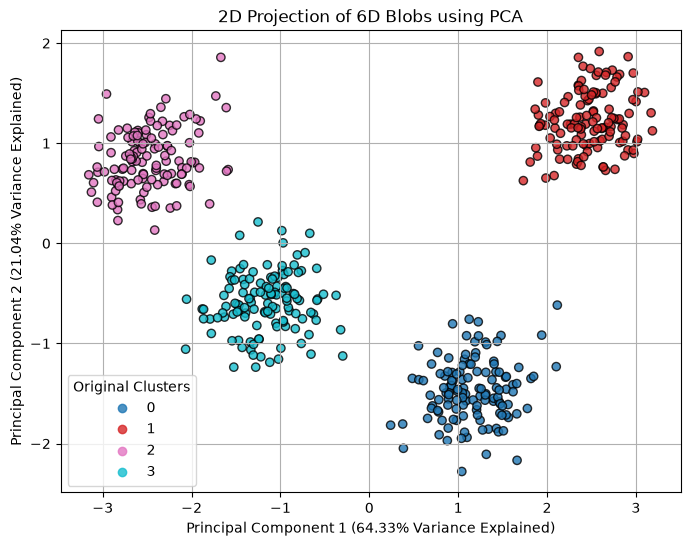

In [11]:
#Question 9: Visualizing PCA Results
import matplotlib.pyplot as plt

# Create Scatter Plot of PC1 vs PC2
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_pca['PC1'], 
    df_pca['PC2'], 
    c=df_pca['Original_Label'], 
    cmap='tab10', 
    edgecolors='k', 
    alpha=0.8
)

# Proper title and axis labels incorporating variance ratios
plt.title("2D Projection of 6D Blobs using PCA", fontsize=12)
plt.xlabel(f"Principal Component 1 ({var_ratio[0]*100:.2f}% Variance Explained)")
plt.ylabel(f"Principal Component 2 ({var_ratio[1]*100:.2f}% Variance Explained)")
plt.legend(*scatter.legend_elements(), title="Original Clusters")
plt.grid(True)

plt.show()

Features selected (13): ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Explained Variance Ratio: PC1=36.20%, PC2=19.21%
Total Variance Retained: 55.41%

DBSCAN Cluster Distribution:
dbscan_cluster
 0    94
-1    42
 1    42
Name: count, dtype: int64


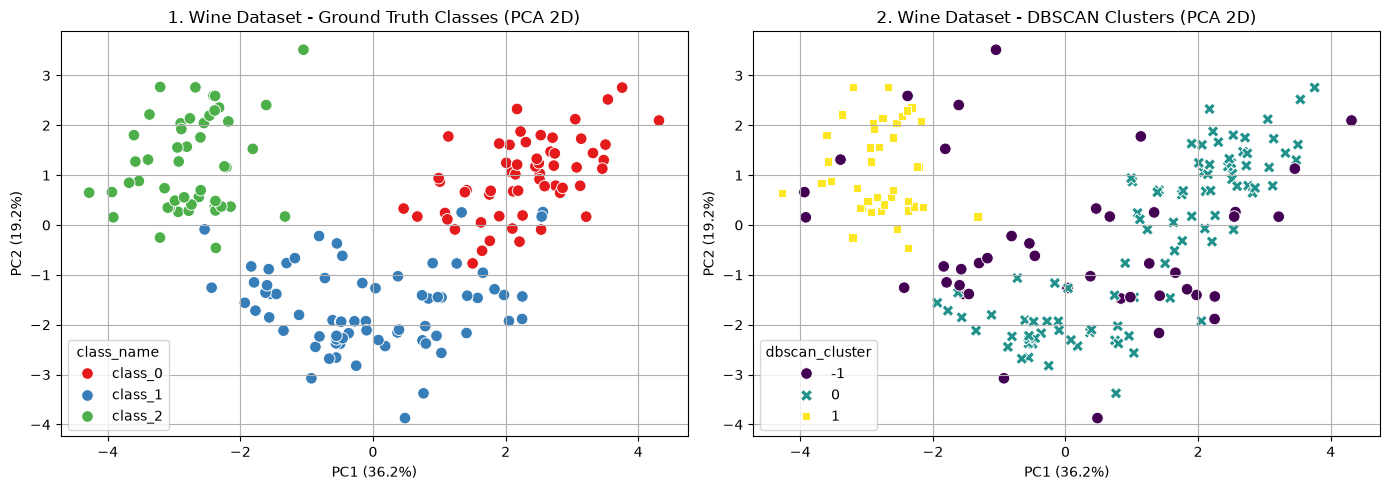

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# 1. Load dataset
df = pd.read_csv('wine_dataset.csv')

# 2. Select numerical features
features = [c for c in df.select_dtypes(include=['float64', 'int64']).columns if c not in ['target']]
X = df[features]

# 3. Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Apply DBSCAN
dbscan = DBSCAN(eps=2.3, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# 5. Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

var_ratio = pca.explained_variance_ratio_

# Print key metrics
print(f"Features selected ({len(features)}): {features}")
print(f"Explained Variance Ratio: PC1={var_ratio[0]*100:.2f}%, PC2={var_ratio[1]*100:.2f}%")
print(f"Total Variance Retained: {var_ratio.sum()*100:.2f}%")
print("\nDBSCAN Cluster Distribution:")
print(df['dbscan_cluster'].value_counts())

# 6. Visualize PCA & DBSCAN results
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='PC1', y='PC2', hue='class_name', palette='Set1', s=70)
plt.title("1. Wine Dataset - Ground Truth Classes (PCA 2D)")
plt.xlabel(f"PC1 ({var_ratio[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_ratio[1]*100:.1f}%)")
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='PC1', y='PC2', hue='dbscan_cluster', style='dbscan_cluster', palette='viridis', s=70)
plt.title("2. Wine Dataset - DBSCAN Clusters (PCA 2D)")
plt.xlabel(f"PC1 ({var_ratio[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_ratio[1]*100:.1f}%)")
plt.grid(True)

plt.tight_layout()
plt.savefig('q10_wine_pipeline.png')
plt.show()